<a href="https://colab.research.google.com/github/B23BB1046/.github.io/blob/main/VQA_Encoder_Decoder_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Lab: Visual Question Answering with Encoder–Decoder Architectures

---

**Objective:** Build an end-to-end Visual Question Answering (VQA) system that takes an **image** and a **natural-language question** as input and predicts the **answer** , using the encoder–decoder framework shown below.




---
## Part 1 : Problem Formulation

### 1.1 What is VQA?

Given an image $I$ and a question $q = (q_1, q_2, \dots, q_T)$, the task is to predict the correct answer $y$ from a fixed vocabulary of possible answers.

### 1.2 The Encoder–Decoder Framework

We follow the classic architecture from [Antol et al., 2015]:

**Encoder** (two parallel branches):

$$\hat{h}_I = \text{CNN}(I) \quad \text{(image encoder)}$$
$$\tilde{h}_t = \text{RNN}(\tilde{h}_{t-1},\; q_t) \quad \text{(question encoder)}$$

The two representations are then fused:

$$s = [\tilde{h}_T \;; \hat{h}_I]$$

**Decoder** (classification head):

$$P(y \mid q, I) = \text{softmax}(Vs + b)$$

**Loss:** Standard cross-entropy over the answer vocabulary:

$$\mathcal{L}(\theta) = -\log P(y = \ell \mid I, q)$$

### 1.3 Why This Architecture?

This design is elegant because each modality is handled by a specialist:
- **CNNs** are strong at extracting spatial and visual features.
- **RNNs/LSTMs** are strong at modelling the sequential structure of language.
- The **fusion + softmax** layer learns to combine both modalities to classify the answer.

Let's build each piece step by step.

---
## 0 : Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw
import math, random, time, json
from collections import Counter

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

Using device: cuda


---
## Part 2 : Building a Synthetic VQA Dataset

Real VQA datasets (VQA v2, GQA) are huge. Instead, we create a **self-contained synthetic dataset** of images with colored geometric shapes and questions about them. This keeps the lab lightweight while preserving all the architectural ideas.

Each image contains **1–3 shapes** with different colors, sizes, and positions.  
Questions probe: color, shape type, counting, and spatial relationships.

### 2.1 Image & Question Generator

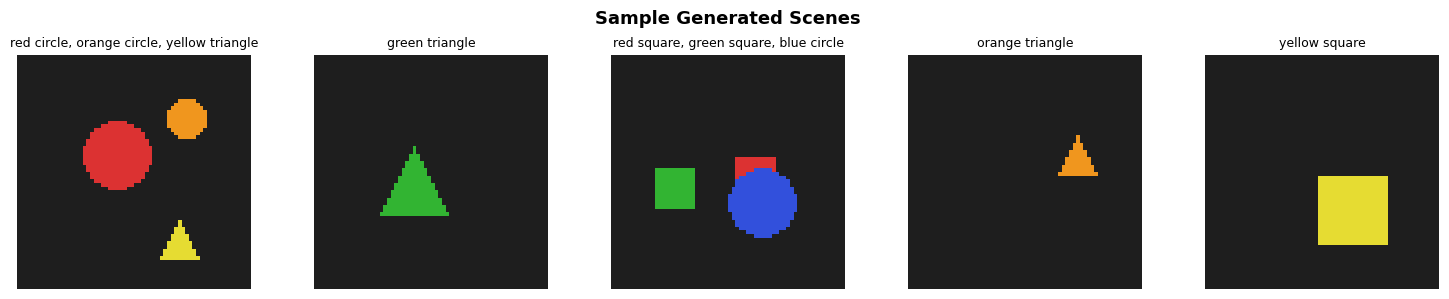

In [ ]:
# --- Configuration ---
IMG_SIZE = 64  # Small images for fast training

COLORS = {
    'red':    (220, 50, 50),
    'green':  (50, 180, 50),
    'blue':   (50, 80, 220),
    'yellow': (230, 220, 50),
    'purple': (160, 50, 200),
    'orange': (240, 150, 30),
}
SHAPES = ['circle', 'square', 'triangle']
SIZES  = ['small', 'large']


def draw_shape(draw, shape, color_rgb, cx, cy, size):
    """Draw a single shape on a PIL ImageDraw canvas."""
    r = size // 2
    if shape == 'circle':
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color_rgb)
    elif shape == 'square':
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=color_rgb)
    elif shape == 'triangle':
        pts = [(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)]
        draw.polygon(pts, fill=color_rgb)


def generate_scene(n_shapes=None):
    """Generate a random scene with 1-3 shapes. Returns image array and scene metadata."""
    if n_shapes is None:
        n_shapes = random.randint(1, 3)

    img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=(30, 30, 30))  # Dark background
    draw = ImageDraw.Draw(img)

    objects = []
    occupied = []  # Track positions to avoid overlap

    for _ in range(n_shapes):
        shape = random.choice(SHAPES)
        color_name = random.choice(list(COLORS.keys()))
        color_rgb = COLORS[color_name]
        size_name = random.choice(SIZES)
        px_size = 10 if size_name == 'small' else 18

        # Place with some randomness, avoiding edges
        for attempt in range(20):
            cx = random.randint(px_size + 2, IMG_SIZE - px_size - 2)
            cy = random.randint(px_size + 2, IMG_SIZE - px_size - 2)
            # Check overlap
            if all(abs(cx - ox) > 16 or abs(cy - oy) > 16 for ox, oy in occupied):
                break

        occupied.append((cx, cy))
        draw_shape(draw, shape, color_rgb, cx, cy, px_size)

        position = 'left' if cx < IMG_SIZE // 2 else 'right'
        objects.append({
            'shape': shape, 'color': color_name,
            'size': size_name, 'position': position,
            'cx': cx, 'cy': cy
        })

    img_array = np.array(img, dtype=np.float32) / 255.0  # Normalise to [0, 1]
    return img_array, objects


# --- Visualise some samples ---
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax in axes:
    img, objs = generate_scene()
    ax.imshow(img)
    desc = ', '.join(f"{o['color']} {o['shape']}" for o in objs)
    ax.set_title(desc, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Generated Scenes', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.2 Question Templates

We define four question *types*, each requiring different reasoning:

In [ ]:
def generate_qa_pairs(objects):
    """Generate diverse question-answer pairs for a given scene."""
    qa_pairs = []
    n = len(objects)

    # Type 1: Color identification
    # "What color is the <shape>?"
    for obj in objects:
        # Only ask if this shape type is unique in the scene
        same_shape = [o for o in objects if o['shape'] == obj['shape']]
        if len(same_shape) == 1:
            qa_pairs.append({
                'question': f"what color is the {obj['shape']}",
                'answer': obj['color'],
                'type': 'color'
            })

    # Type 2: Shape identification
    # "What shape is the <color> object?"
    for obj in objects:
        same_color = [o for o in objects if o['color'] == obj['color']]
        if len(same_color) == 1:
            qa_pairs.append({
                'question': f"what shape is the {obj['color']} object",
                'answer': obj['shape'],
                'type': 'shape'
            })

    #  Type 3: Counting
    # "How many objects are there?"
    count_map = {1: 'one', 2: 'two', 3: 'three'}
    qa_pairs.append({
        'question': 'how many objects are there',
        'answer': count_map[n],
        'type': 'count'
    })

    # "How many <shape>s are there?"
    for shape in SHAPES:
        cnt = sum(1 for o in objects if o['shape'] == shape)
        if cnt > 0:
            qa_pairs.append({
                'question': f"how many {shape}s are there",
                'answer': count_map.get(cnt, str(cnt)),
                'type': 'count'
            })

    #  Type 4: Existence / Yes-No
    # "Is there a <color> <shape>?"
    for color in random.sample(list(COLORS.keys()), 3):
        for shape in random.sample(SHAPES, 2):
            exists = any(o['color'] == color and o['shape'] == shape for o in objects)
            qa_pairs.append({
                'question': f"is there a {color} {shape}",
                'answer': 'yes' if exists else 'no',
                'type': 'existence'
            })

    return qa_pairs


# Quick test
test_img, test_objs = generate_scene(n_shapes=2)
test_qas = generate_qa_pairs(test_objs)

desc = [o['color'] + ' ' + o['shape'] for o in test_objs]
print(f"Scene: {desc}")
print(f"\nGenerated {len(test_qas)} QA pairs:")
for qa in test_qas[:8]:
    print(f"  Q: {qa['question']:45s}  A: {qa['answer']:10s}  [{qa['type']}]")

Scene: ['green triangle', 'green circle']

Generated 11 QA pairs:
  Q: what color is the triangle                     A: green       [color]
  Q: what color is the circle                       A: green       [color]
  Q: how many objects are there                     A: two         [count]
  Q: how many circles are there                     A: one         [count]
  Q: how many triangles are there                   A: one         [count]
  Q: is there a green circle                        A: yes         [existence]
  Q: is there a green square                        A: no          [existence]
  Q: is there a purple square                       A: no          [existence]


### 2.3 Build the Full Dataset

In [ ]:
def build_dataset(n_scenes=2000, max_qa_per_scene=5):
    """Generate scenes and collect QA pairs into a flat dataset."""
    data = []
    for _ in range(n_scenes):
        img, objs = generate_scene()
        qas = generate_qa_pairs(objs)
        # Subsample to keep dataset balanced
        selected = random.sample(qas, min(len(qas), max_qa_per_scene))
        for qa in selected:
            data.append({
                'image': img,
                'question': qa['question'],
                'answer': qa['answer'],
                'type': qa['type']
            })
    return data


print("Generating dataset...")
all_data = build_dataset(n_scenes=3000, max_qa_per_scene=4)
random.shuffle(all_data)

# Split: 80% train, 10% val, 10% test
n = len(all_data)
train_data = all_data[:int(0.8 * n)]
val_data   = all_data[int(0.8 * n):int(0.9 * n)]
test_data  = all_data[int(0.9 * n):]

print(f"\nTotal samples: {n:,}")
print(f"  Train: {len(train_data):,}  Val: {len(val_data):,}  Test: {len(test_data):,}")

# Answer distribution
ans_counts = Counter(d['answer'] for d in all_data)
type_counts = Counter(d['type'] for d in all_data)
print(f"\nAnswer vocabulary size: {len(ans_counts)}")
print(f"Question types: {dict(type_counts)}")

Generating dataset...

Total samples: 12,000
  Train: 9,600  Val: 1,200  Test: 1,200

Answer vocabulary size: 14
Question types: {'count': 2696, 'existence': 6425, 'shape': 1638, 'color': 1241}


### 2.4 Vocabulary & Tokenisation

In [ ]:
class Vocabulary:
    """Simple word-level vocabulary with <PAD> and <UNK> tokens."""

    def __init__(self):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}

    def build(self, sentences):
        for sent in sentences:
            for word in sent.lower().split():
                if word not in self.word2idx:
                    idx = len(self.word2idx)
                    self.word2idx[word] = idx
                    self.idx2word[idx] = word

    def encode(self, sentence, max_len):
        tokens = sentence.lower().split()
        ids = [self.word2idx.get(w, 1) for w in tokens]  # 1 = <UNK>
        # Pad or truncate
        ids = ids[:max_len] + [0] * max(0, max_len - len(ids))
        return ids

    def __len__(self):
        return len(self.word2idx)


# Build question vocabulary
question_vocab = Vocabulary()
question_vocab.build([d['question'] for d in all_data])

# Build answer vocabulary (each answer is a single class)
all_answers = sorted(set(d['answer'] for d in all_data))
answer2idx = {a: i for i, a in enumerate(all_answers)}
idx2answer = {i: a for a, i in answer2idx.items()}
num_answers = len(all_answers)

MAX_Q_LEN = 8  # Max question length in tokens

print(f"Question vocab size: {len(question_vocab)}")
print(f"Answer classes: {num_answers} → {all_answers}")

# Test encoding
sample_q = "what color is the circle"
encoded = question_vocab.encode(sample_q, MAX_Q_LEN)
print(f"\nEncoding '{sample_q}' → {encoded}")

Question vocab size: 26
Answer classes: 14 → ['blue', 'circle', 'green', 'no', 'one', 'orange', 'purple', 'red', 'square', 'three', 'triangle', 'two', 'yellow', 'yes']

Encoding 'what color is the circle' → [13, 19, 7, 15, 12, 0, 0, 0]


### 2.5 PyTorch Dataset & DataLoader

In [ ]:
class VQADataset(Dataset):
    """Custom dataset for our synthetic VQA task."""

    def __init__(self, data, question_vocab, answer2idx, max_q_len=8):
        self.data = data
        self.question_vocab = question_vocab
        self.answer2idx = answer2idx
        self.max_q_len = max_q_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Image: (H, W, C) → (C, H, W) for PyTorch
        image = torch.FloatTensor(item['image']).permute(2, 0, 1)

        # Question: tokenise + pad
        q_ids = self.question_vocab.encode(item['question'], self.max_q_len)
        question = torch.LongTensor(q_ids)

        # Answer: integer class
        answer = self.answer2idx[item['answer']]

        return image, question, answer


BATCH_SIZE = 128

train_ds = VQADataset(train_data, question_vocab, answer2idx, MAX_Q_LEN)
val_ds   = VQADataset(val_data,   question_vocab, answer2idx, MAX_Q_LEN)
test_ds  = VQADataset(test_data,  question_vocab, answer2idx, MAX_Q_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# Verify shapes
imgs, qs, ans = next(iter(train_loader))
print(f"Image batch:    {imgs.shape}   (B, C, H, W)")
print(f"Question batch: {qs.shape}     (B, max_len)")
print(f"Answer batch:   {ans.shape}        (B,)")

Image batch:    torch.Size([128, 3, 64, 64])   (B, C, H, W)
Question batch: torch.Size([128, 8])     (B, max_len)
Answer batch:   torch.Size([128])        (B,)


---
## Part 3 : Image Encoder: CNN

The image encoder maps a raw image to a fixed-length feature vector:

$$\hat{h}_I = \text{CNN}(I) \in \mathbb{R}^{d_I}$$

For real VQA you'd use a pretrained ResNet/VGG. For our 64×64 synthetic images, a small custom CNN suffices and lets us see every layer.

### 3.1 Architecture

In [ ]:
class ImageEncoder(nn.Module):
    """
    Small CNN that maps a 64×64 RGB image to a feature vector.

    Architecture:
        Conv(3→32) → ReLU → MaxPool
        Conv(32→64) → ReLU → MaxPool
        Conv(64→128) → ReLU → AdaptiveAvgPool
        Linear → image embedding
    """

    def __init__(self, embed_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),             # 64→32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),             # 32→16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)) # → (128, 2, 2)
        )
        self.fc = nn.Linear(128 * 2 * 2, embed_dim)

    def forward(self, x):
        """x: (B, 3, 64, 64) → (B, embed_dim)"""
        feat = self.features(x)          # (B, 128, 2, 2)
        feat = feat.view(feat.size(0), -1)  # Flatten
        h_I = self.fc(feat)              # (B, embed_dim)
        return h_I


#  Test
img_enc = ImageEncoder(embed_dim=128).to(device)
dummy_img = torch.randn(4, 3, 64, 64).to(device)
h_I = img_enc(dummy_img)
print(f"Image encoder output: {h_I.shape}  ← this is ĥ_I")
print(f"Parameters: {sum(p.numel() for p in img_enc.parameters()):,}")

Image encoder output: torch.Size([4, 128])  ← this is ĥ_I
Parameters: 159,360


### 3.2 What Does the CNN See?

Let's visualise the intermediate feature maps to build intuition.

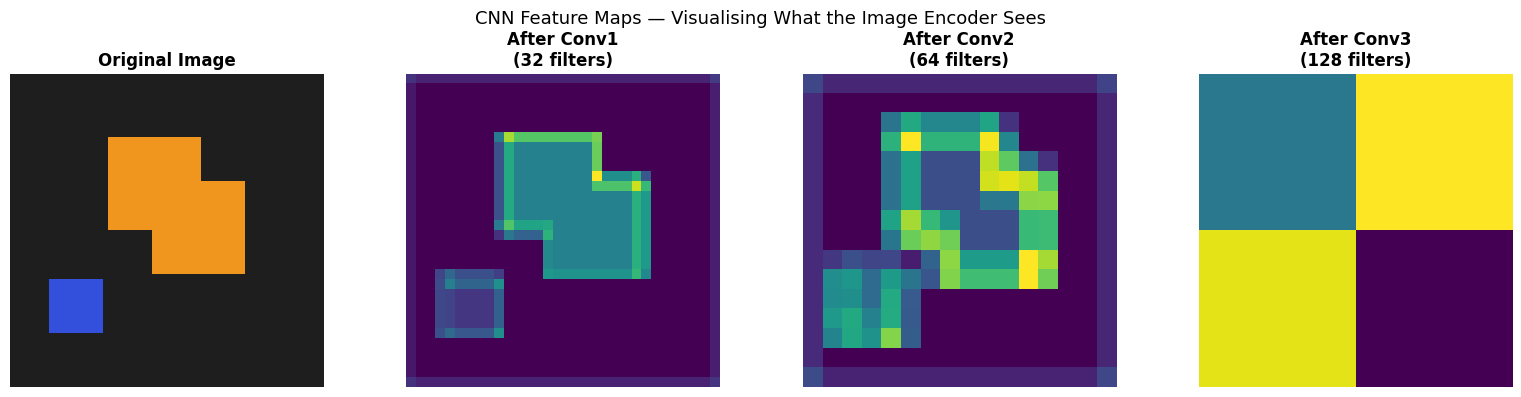

In [ ]:
# Grab a sample image and pass through each conv layer
sample_img_tensor = torch.FloatTensor(test_data[0]['image']).permute(2, 0, 1).unsqueeze(0).to(device)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original image
axes[0].imshow(test_data[0]['image'])
axes[0].set_title('Original Image', fontweight='bold')

# Feature maps after each conv block
x = sample_img_tensor
layer_names = ['After Conv1\n(32 filters)', 'After Conv2\n(64 filters)', 'After Conv3\n(128 filters)']

for i, layer_idx in enumerate([3, 7, 11]):  # After each ReLU
    partial_model = nn.Sequential(*list(img_enc.features.children())[:layer_idx + 1])
    with torch.no_grad():
        feat = partial_model(x)
    # Show mean across channels
    feat_map = feat[0].mean(dim=0).cpu().numpy()
    axes[i + 1].imshow(feat_map, cmap='viridis')
    axes[i + 1].set_title(layer_names[i], fontweight='bold')

for ax in axes:
    ax.axis('off')
plt.suptitle('CNN Feature Maps — Visualising What the Image Encoder Sees', fontsize=13)
plt.tight_layout(); plt.show()

---
## Part 4 : Question Encoder: LSTM

The question encoder reads word tokens sequentially and produces a summary vector:

$$e_t = \text{Embedding}(q_t)$$
$$\tilde{h}_t = \text{LSTM}(\tilde{h}_{t-1},\; e_t)$$

We take the **last hidden state** $\tilde{h}_T$ as the question representation.

### 4.1 Architecture

In [ ]:
class QuestionEncoder(nn.Module):
    """
    Embeds question words and runs an LSTM over them.
    Returns the final hidden state as the question representation.
    """

    def __init__(self, vocab_size, embed_dim=64, hidden_size=128,
                 num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_size, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )

    def forward(self, q):
        """q: (B, T) integer token ids → (B, hidden_size)"""
        emb = self.embedding(q)       # (B, T, embed_dim)
        out, (h_n, c_n) = self.lstm(emb)  # h_n: (num_layers, B, H)
        h_T = h_n[-1]                 # Last layer's final hidden state
        return h_T


# Test
q_enc = QuestionEncoder(len(question_vocab), embed_dim=64, hidden_size=128).to(device)
dummy_q = torch.randint(0, len(question_vocab), (4, MAX_Q_LEN)).to(device)
h_Q = q_enc(dummy_q)
print(f"Question encoder output: {h_Q.shape}  ← this is h̃_T")
print(f"Parameters: {sum(p.numel() for p in q_enc.parameters()):,}")

Question encoder output: torch.Size([4, 128])  ← this is h̃_T
Parameters: 100,992


### 4.2 Visualising the LSTM's Hidden State Over Time

Let's watch how the hidden state evolves as the LSTM reads each word.

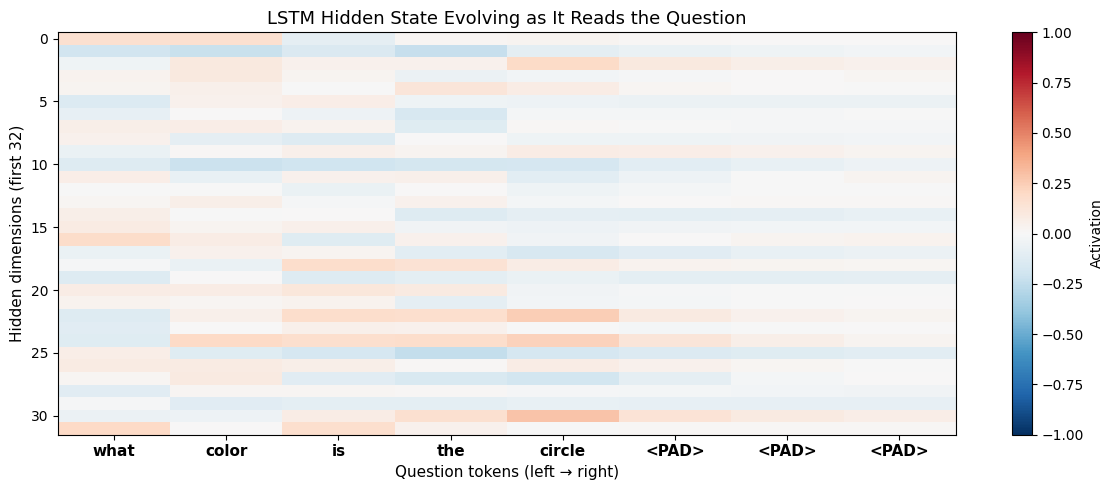

→ Each column is the hidden state after reading that word.
  The final column (h̃_T) summarises the entire question.


In [ ]:
# Encode a specific question and track all hidden states
sample_question = "what color is the circle"
q_ids = question_vocab.encode(sample_question, MAX_Q_LEN)
q_tensor = torch.LongTensor([q_ids]).to(device)

with torch.no_grad():
    emb = q_enc.embedding(q_tensor)       # (1, T, embed)
    all_out, _ = q_enc.lstm(emb)           # (1, T, H)
    hidden_states = all_out[0].cpu().numpy()  # (T, H)

words = sample_question.split() + ['<PAD>'] * (MAX_Q_LEN - len(sample_question.split()))

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(hidden_states.T[:32, :], aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(MAX_Q_LEN))
ax.set_xticklabels(words, fontsize=11, fontweight='bold')
ax.set_ylabel('Hidden dimensions (first 32)', fontsize=11)
ax.set_xlabel('Question tokens (left → right)', fontsize=11)
ax.set_title('LSTM Hidden State Evolving as It Reads the Question', fontsize=13)
plt.colorbar(im, ax=ax, label='Activation')
plt.tight_layout(); plt.show()

print("→ Each column is the hidden state after reading that word.")
print("  The final column (h̃_T) summarises the entire question.")

---
## Part 5 : Multimodal Fusion & Decoder

### 5.1 Fusion Strategies

The fusion step combines the image and question representations. We'll implement three common strategies:

| Strategy | Formula | Pros |
|---|---|---|
| **Concatenation** | $s = [\tilde{h}_T \;; \hat{h}_I]$ | Simple, preserves all info |
| **Element-wise multiply** | $s = \tilde{h}_T \odot \hat{h}_I$ | Captures interactions, compact |
| **Addition** | $s = \tilde{h}_T + \hat{h}_I$ | Simplest, can work surprisingly well |

In [ ]:
class MultimodalFusion(nn.Module):
    """Fuses image and question representations."""

    def __init__(self, img_dim, q_dim, fusion_dim, method='concat'):
        super().__init__()
        self.method = method

        if method == 'concat':
            self.proj = nn.Linear(img_dim + q_dim, fusion_dim)
        elif method == 'multiply':
            # Project both to same dim first
            self.proj_img = nn.Linear(img_dim, fusion_dim)
            self.proj_q   = nn.Linear(q_dim, fusion_dim)
        elif method == 'add':
            self.proj_img = nn.Linear(img_dim, fusion_dim)
            self.proj_q   = nn.Linear(q_dim, fusion_dim)

        self.output_dim = fusion_dim

    def forward(self, h_I, h_Q):
        if self.method == 'concat':
            s = torch.cat([h_Q, h_I], dim=-1)  # [h̃_T ; ĥ_I]
            s = torch.relu(self.proj(s))
        elif self.method == 'multiply':
            s = torch.relu(self.proj_img(h_I)) * torch.relu(self.proj_q(h_Q))
        elif self.method == 'add':
            s = torch.relu(self.proj_img(h_I)) + torch.relu(self.proj_q(h_Q))
        return s


# Test each fusion method
for method in ['concat', 'multiply', 'add']:
    fuse = MultimodalFusion(128, 128, 256, method=method)
    s = fuse(torch.randn(4, 128), torch.randn(4, 128))
    print(f"{method:10s} fusion → output shape: {s.shape}")

concat     fusion → output shape: torch.Size([4, 256])
multiply   fusion → output shape: torch.Size([4, 256])
add        fusion → output shape: torch.Size([4, 256])


### 5.2 Decoder

The decoder is simply a classification head:

$$P(y \mid q, I) = \text{softmax}(V s + b)$$

This is a standard linear layer + softmax (handled by `nn.CrossEntropyLoss`).

---
## Part 6 : Full VQA Model: Training & Evaluation

### 6.1 Putting It All Together

In [ ]:
class VQAModel(nn.Module):
    """
    Complete VQA model: Image Encoder + Question Encoder + Fusion + Decoder.

    Architecture diagram:
        Image  → CNN  → ĥ_I  ─┐
                                ├→ Fusion → s → Linear → softmax → P(answer)
        Question → LSTM → h̃_T ─┘
    """

    def __init__(self, vocab_size, num_answers,
                 img_embed_dim=128, q_embed_dim=64, q_hidden_dim=128,
                 fusion_dim=256, fusion_method='concat', dropout=0.3):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim=img_embed_dim)
        self.question_encoder = QuestionEncoder(
            vocab_size, embed_dim=q_embed_dim, hidden_size=q_hidden_dim)
        self.fusion = MultimodalFusion(
            img_embed_dim, q_hidden_dim, fusion_dim, method=fusion_method)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(fusion_dim, num_answers)  # Decoder: Vs + b

    def forward(self, image, question):
        h_I = self.image_encoder(image)       # ĥ_I
        h_Q = self.question_encoder(question)  # h̃_T
        s   = self.fusion(h_I, h_Q)            # s = fuse(h̃_T, ĥ_I)
        s   = self.dropout(s)
        logits = self.classifier(s)            # Vs + b
        return logits  # Raw logits (softmax is in CrossEntropyLoss)


#  Instantiate
model = VQAModel(
    vocab_size=len(question_vocab),
    num_answers=num_answers,
    fusion_method='concat'
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nVQA Model — Total parameters: {total_params:,}")
print(f"  Image encoder:    {sum(p.numel() for p in model.image_encoder.parameters()):,}")
print(f"  Question encoder: {sum(p.numel() for p in model.question_encoder.parameters()):,}")
print(f"  Fusion + decoder: {sum(p.numel() for p in model.fusion.parameters()) + sum(p.numel() for p in model.classifier.parameters()):,}")


VQA Model — Total parameters: 329,742
  Image encoder:    159,360
  Question encoder: 100,992
  Fusion + decoder: 69,390


### 6.2 Training Loop

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, questions, answers in loader:
        images    = images.to(device)
        questions = questions.to(device)
        answers   = answers.to(device)

        logits = model(images, questions)
        loss = criterion(logits, answers)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * answers.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == answers).sum().item()
        total += answers.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, questions, answers in loader:
        images    = images.to(device)
        questions = questions.to(device)
        answers   = answers.to(device)

        logits = model(images, questions)
        loss = criterion(logits, answers)

        total_loss += loss.item() * answers.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == answers).sum().item()
        total += answers.size(0)

    return total_loss / total, correct / total

### 6.3 Train!

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

EPOCHS = 25
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_model_state = None

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>10} | {'Val Acc':>9}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:5d} | {train_loss:10.4f} | {train_acc:8.1%} | {val_loss:10.4f} | {val_acc:8.1%}")

print(f"\n Best validation accuracy: {best_val_acc:.1%}")

Epoch | Train Loss | Train Acc |   Val Loss |   Val Acc
------------------------------------------------------------
    1 |     1.2021 |    60.1% |     0.7378 |    65.8%
    5 |     0.5772 |    75.4% |     0.6076 |    74.8%
   10 |     0.4774 |    81.3% |     0.6183 |    74.6%
   15 |     0.4053 |    84.0% |     0.4463 |    81.8%
   20 |     0.3477 |    85.2% |     0.4299 |    81.9%
   25 |     0.3120 |    86.4% |     0.3833 |    83.1%

 Best validation accuracy: 83.1%


### 6.4 Training Curves

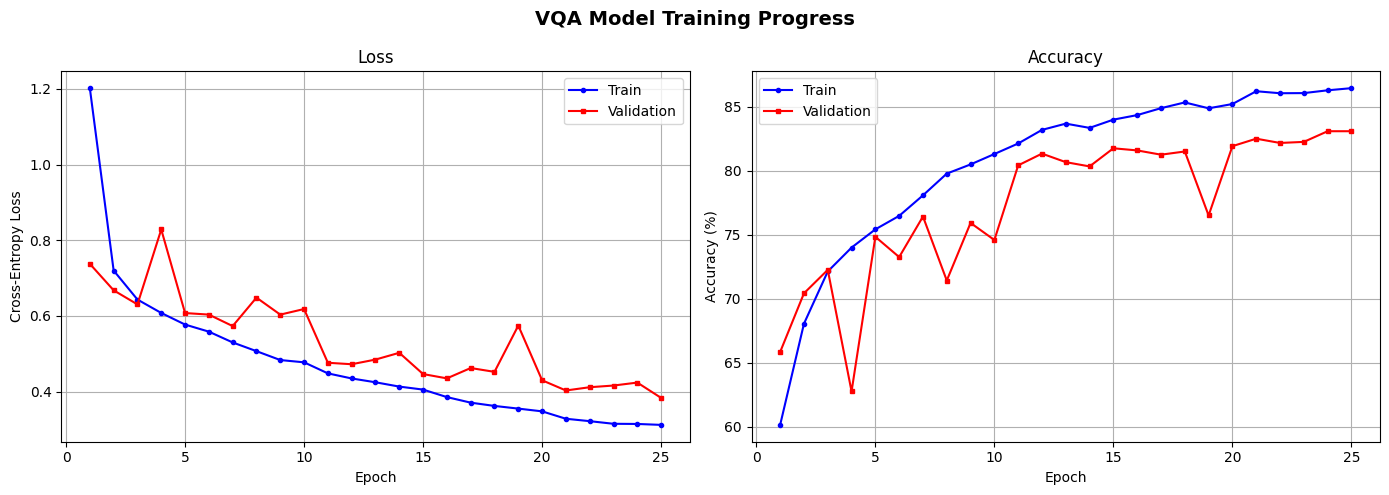

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', markersize=3, label='Train')
ax1.plot(epochs_range, history['val_loss'], 'r-s', markersize=3, label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)

# Accuracy
ax2.plot(epochs_range, [a * 100 for a in history['train_acc']], 'b-o', markersize=3, label='Train')
ax2.plot(epochs_range, [a * 100 for a in history['val_acc']], 'r-s', markersize=3, label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)

fig.suptitle('VQA Model Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 6.5 Test Set Evaluation

In [ ]:
# Load best model
model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Results:")
print(f"   Loss:     {test_loss:.4f}")
print(f"   Accuracy: {test_acc:.1%}")

# Per-type accuracy
type_correct = Counter()
type_total = Counter()

model.eval()
for i, item in enumerate(test_data):
    img = torch.FloatTensor(item['image']).permute(2, 0, 1).unsqueeze(0).to(device)
    q_ids = question_vocab.encode(item['question'], MAX_Q_LEN)
    q = torch.LongTensor([q_ids]).to(device)

    with torch.no_grad():
        logits = model(img, q)
    pred = idx2answer[logits.argmax(dim=1).item()]

    q_type = item['type']
    type_total[q_type] += 1
    if pred == item['answer']:
        type_correct[q_type] += 1

print(f"\n Accuracy by Question Type:")
print(f"   {'Type':<12} {'Correct':>7} / {'Total':>5} = {'Accuracy':>8}")
print("   " + "-" * 42)
for qtype in sorted(type_total.keys()):
    acc = type_correct[qtype] / type_total[qtype]
    print(f"   {qtype:<12} {type_correct[qtype]:>7} / {type_total[qtype]:>5} = {acc:>7.1%}")


Test Results:
   Loss:     0.3900
   Accuracy: 84.6%

 Accuracy by Question Type:
   Type         Correct / Total = Accuracy
   ------------------------------------------
   color             88 /   131 =   67.2%
   count            253 /   281 =   90.0%
   existence        570 /   643 =   88.6%
   shape            104 /   145 =   71.7%


---
## Part 7 — Visualising Predictions

### 7.1 Qualitative Results

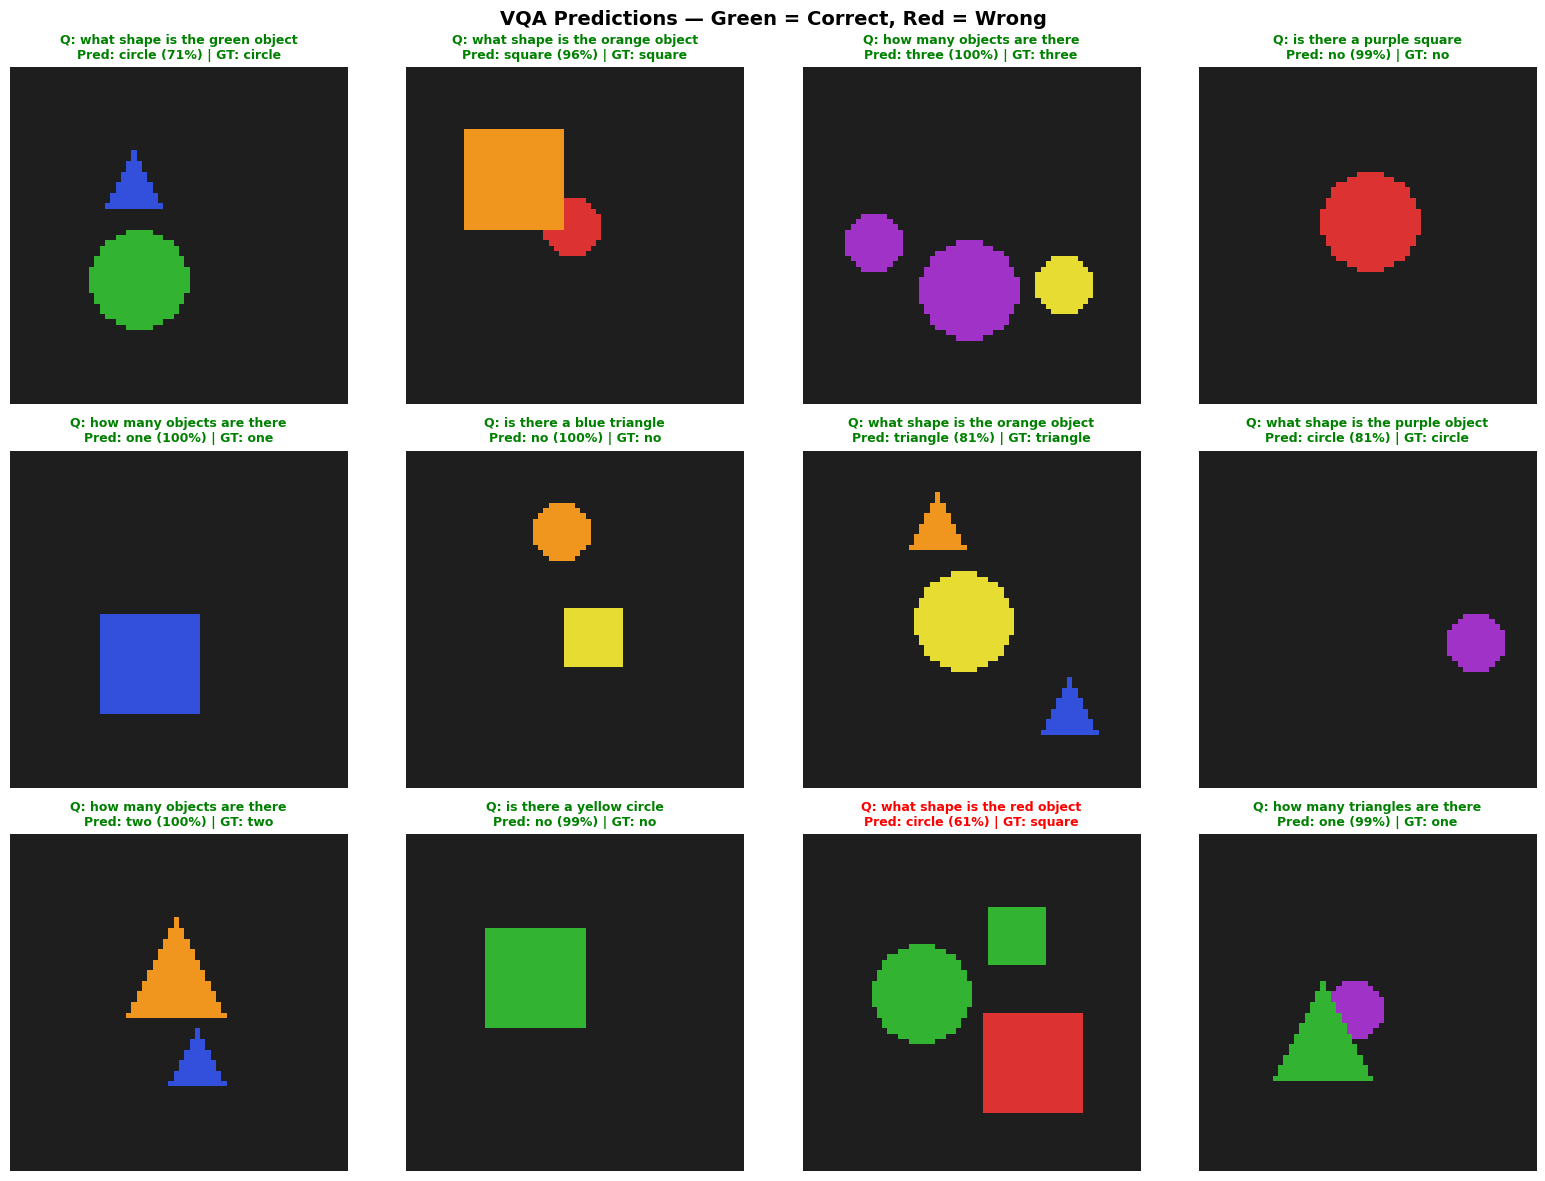

In [ ]:
def predict_and_show(model, data_items, n=12):
    """Show images with predicted vs ground-truth answers."""
    model.eval()
    indices = random.sample(range(len(data_items)), n)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = axes.flatten()

    for ax_idx, data_idx in enumerate(indices):
        item = data_items[data_idx]
        img = torch.FloatTensor(item['image']).permute(2, 0, 1).unsqueeze(0).to(device)
        q_ids = question_vocab.encode(item['question'], MAX_Q_LEN)
        q = torch.LongTensor([q_ids]).to(device)

        with torch.no_grad():
            logits = model(img, q)
            probs = F.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()
        pred_answer = idx2answer[pred_idx]
        confidence = probs[0, pred_idx].item()

        correct = pred_answer == item['answer']
        color = 'green' if correct else 'red'

        ax = axes[ax_idx]
        ax.imshow(item['image'])
        ax.set_title(
            f"Q: {item['question']}\n"
            f"Pred: {pred_answer} ({confidence:.0%}) | GT: {item['answer']}",
            fontsize=9, color=color, fontweight='bold'
        )
        ax.axis('off')

    # Hide unused axes
    for ax_idx in range(n, len(axes)):
        axes[ax_idx].axis('off')

    plt.suptitle('VQA Predictions — Green = Correct, Red = Wrong',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


predict_and_show(model, test_data, n=12)

### 7.2 Confidence Analysis

How confident is the model when it's right vs. wrong?

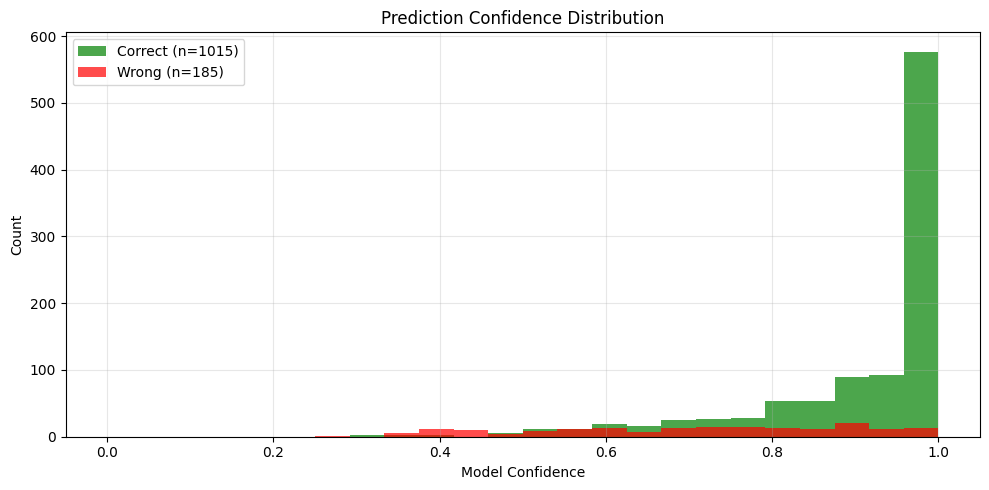

Mean confidence when correct: 0.912
Mean confidence when wrong:   0.701


In [ ]:
correct_confs, wrong_confs = [], []

model.eval()
for item in test_data:
    img = torch.FloatTensor(item['image']).permute(2, 0, 1).unsqueeze(0).to(device)
    q_ids = question_vocab.encode(item['question'], MAX_Q_LEN)
    q = torch.LongTensor([q_ids]).to(device)

    with torch.no_grad():
        logits = model(img, q)
        probs = F.softmax(logits, dim=1)

    pred_idx = logits.argmax(dim=1).item()
    confidence = probs[0, pred_idx].item()
    pred_answer = idx2answer[pred_idx]

    if pred_answer == item['answer']:
        correct_confs.append(confidence)
    else:
        wrong_confs.append(confidence)

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 25)
ax.hist(correct_confs, bins=bins, alpha=0.7, label=f'Correct (n={len(correct_confs)})', color='green')
ax.hist(wrong_confs, bins=bins, alpha=0.7, label=f'Wrong (n={len(wrong_confs)})', color='red')
ax.set_xlabel('Model Confidence'); ax.set_ylabel('Count')
ax.set_title('Prediction Confidence Distribution')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Mean confidence when correct: {np.mean(correct_confs):.3f}")
print(f"Mean confidence when wrong:   {np.mean(wrong_confs):.3f}" if wrong_confs else "No wrong predictions!")

---
## Part 8 : Ablation Studies: What Matters Most?

A good ML lab doesn't just train one model — it asks **what contributes to performance**. Let's run controlled experiments.

### 8.1 Fusion Method Comparison

Training with different fusion methods...

  Training: concat... Final val acc: 82.2%
  Training: multiply... Final val acc: 72.8%
  Training: add... Final val acc: 69.1%


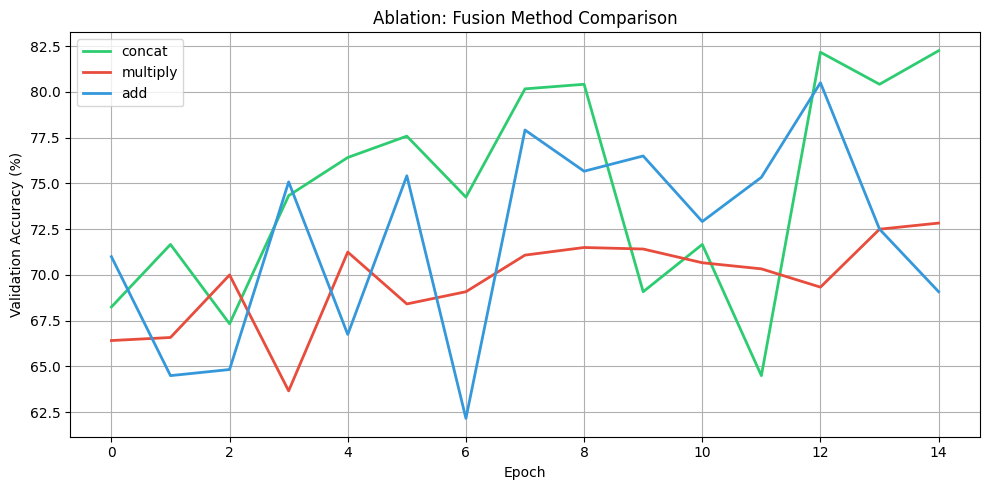

In [ ]:
def quick_train(fusion_method, epochs=15):
    """Train a VQA model with a given fusion method and return val accuracy."""
    m = VQAModel(
        vocab_size=len(question_vocab),
        num_answers=num_answers,
        fusion_method=fusion_method
    ).to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(m.parameters(), lr=1e-3)

    val_accs = []
    for ep in range(1, epochs + 1):
        train_epoch(m, train_loader, crit, opt)
        _, va = evaluate(m, val_loader, crit)
        val_accs.append(va)
    return val_accs


print("Training with different fusion methods...\n")
fusion_results = {}
for method in ['concat', 'multiply', 'add']:
    print(f"  Training: {method}...", end=' ')
    accs = quick_train(method, epochs=15)
    fusion_results[method] = accs
    print(f"Final val acc: {accs[-1]:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors_fusion = {'concat': '#2ecc71', 'multiply': '#e74c3c', 'add': '#3498db'}
for method, accs in fusion_results.items():
    ax.plot([a * 100 for a in accs], label=method, linewidth=2, color=colors_fusion[method])
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Ablation: Fusion Method Comparison')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

### 8.2 Image-Only vs Question-Only Baselines

Does the model *actually* use both modalities? Let's check by zeroing out one input at a time.


 Modality Ablation Results:
   Full model (image + question): 84.6%
   Question only (image zeroed):  28.6%
   Image only (question zeroed):  47.4%


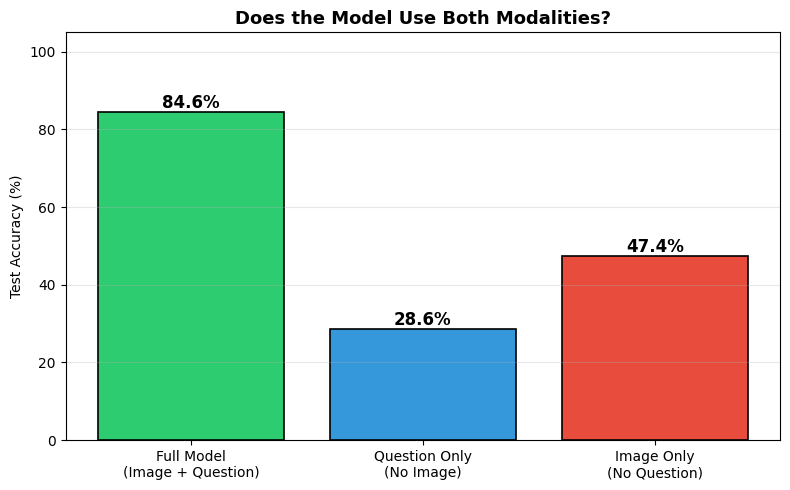


→ If the model truly learns multimodal reasoning, the full model
  should significantly outperform both single-modality baselines.


In [ ]:
# Load the best model
model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
model.eval()

def evaluate_ablated(model, loader, zero_image=False, zero_question=False):
    """Evaluate with one modality zeroed out."""
    correct, total = 0, 0
    for images, questions, answers in loader:
        images    = images.to(device)
        questions = questions.to(device)
        answers   = answers.to(device)

        if zero_image:
            images = torch.zeros_like(images)
        if zero_question:
            questions = torch.zeros_like(questions)

        with torch.no_grad():
            logits = model(images, questions)
        preds = logits.argmax(dim=1)
        correct += (preds == answers).sum().item()
        total += answers.size(0)

    return correct / total


full_acc = evaluate_ablated(model, test_loader, False, False)
no_img_acc = evaluate_ablated(model, test_loader, True, False)
no_q_acc = evaluate_ablated(model, test_loader, False, True)

print("\n Modality Ablation Results:")
print(f"   Full model (image + question): {full_acc:.1%}")
print(f"   Question only (image zeroed):  {no_img_acc:.1%}")
print(f"   Image only (question zeroed):  {no_q_acc:.1%}")

# Visualise
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ['Full Model\n(Image + Question)', 'Question Only\n(No Image)', 'Image Only\n(No Question)'],
    [full_acc * 100, no_img_acc * 100, no_q_acc * 100],
    color=['#2ecc71', '#3498db', '#e74c3c'],
    edgecolor='black', linewidth=1.2
)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Does the Model Use Both Modalities?', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, [full_acc, no_img_acc, no_q_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1%}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print("\n→ If the model truly learns multimodal reasoning, the full model")
print("  should significantly outperform both single-modality baselines.")

### 8.3 Error Analysis

Let's look at what the model gets wrong — this is often more informative than what it gets right.

Total errors: 185 / 1200  (15.4%)



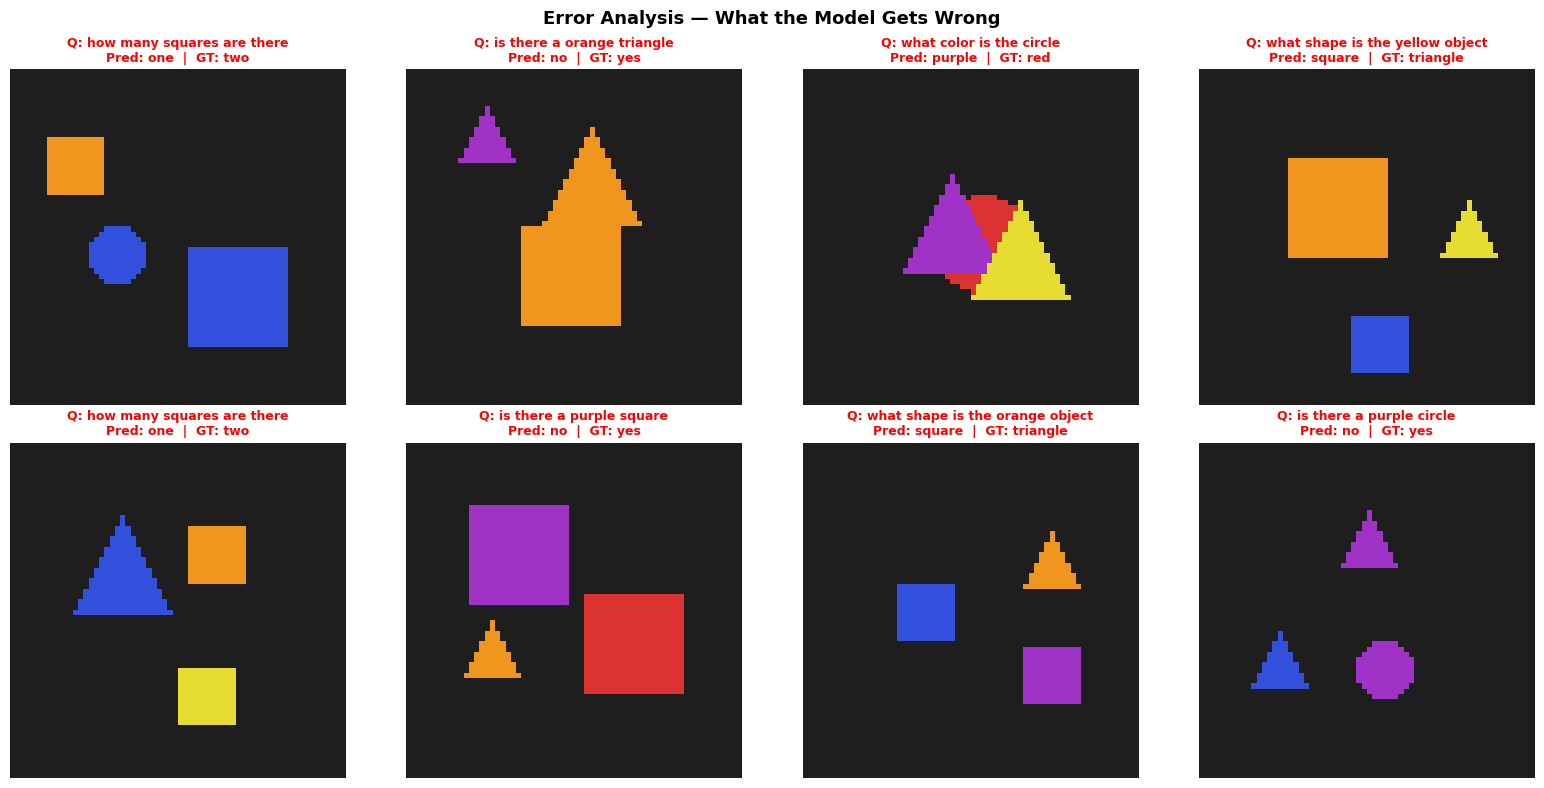

Error distribution by question type:
  existence: 73 errors
  color: 43 errors
  shape: 41 errors
  count: 28 errors


In [ ]:
# Collect errors
errors = []
model.eval()

for item in test_data:
    img = torch.FloatTensor(item['image']).permute(2, 0, 1).unsqueeze(0).to(device)
    q_ids = question_vocab.encode(item['question'], MAX_Q_LEN)
    q = torch.LongTensor([q_ids]).to(device)

    with torch.no_grad():
        logits = model(img, q)
    pred = idx2answer[logits.argmax(dim=1).item()]

    if pred != item['answer']:
        errors.append({**item, 'predicted': pred})

print(f"Total errors: {len(errors)} / {len(test_data)}  ({len(errors)/len(test_data):.1%})\n")

if errors:
    # Show some errors
    n_show = min(8, len(errors))
    ncols = 4
    nrows = math.ceil(n_show / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).flatten()

    for i in range(n_show):
        e = errors[i]
        axes[i].imshow(e['image'])
        axes[i].set_title(
            f"Q: {e['question']}\n"
            f"Pred: {e['predicted']}  |  GT: {e['answer']}",
            fontsize=9, color='red', fontweight='bold'
        )
        axes[i].axis('off')
    for i in range(n_show, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Error Analysis — What the Model Gets Wrong', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Error type distribution
    err_types = Counter(e['type'] for e in errors)
    print("Error distribution by question type:")
    for qt, cnt in err_types.most_common():
        print(f"  {qt}: {cnt} errors")
else:
    print(" No errors on the test set!")

---
## Part 9 : Exercises & Further Reading

###  Exercises

1. **GRU vs LSTM question encoder:** Replace `nn.LSTM` with `nn.GRU` in `QuestionEncoder`. Does it change accuracy? Training speed?

2. **Pretrained CNN backbone:** Replace `ImageEncoder` with a pretrained `torchvision.models.resnet18(pretrained=True)` (remove the final FC layer). Does transfer learning help even on synthetic data?



### Further Reading

| Resource | Link |
|---|---|
| VQA: Visual Question Answering (Antol et al., 2015) | [arxiv.org/abs/1505.00468](https://arxiv.org/abs/1505.00468) |
|
| CLEVR dataset (similar to our synthetic data!) | [cs.stanford.edu/people/jcjohns/clevr](https://cs.stanford.edu/people/jcjohns/clevr/) |
|  |
| VQA v2 dataset & challenge | [visualqa.org](https://visualqa.org/) |
| Colah's Understanding LSTMs | [colah.github.io/posts/2015-08-Understanding-LSTMs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) |

---

###  Summary

| Component | What we built | Key idea |
|---|---|---|
| **Image Encoder** | 3-layer CNN | Spatial features → fixed-length vector $\hat{h}_I$ |
| **Question Encoder** | Word embedding + LSTM | Sequential tokens → summary vector $\tilde{h}_T$ |
| **Fusion** | Concatenation / Multiply / Add | Combine two modalities into joint representation $s$ |
| **Decoder** | Linear + softmax | $P(y \mid q, I) = \text{softmax}(Vs + b)$ |
| **Training** | Cross-entropy + Adam + grad clipping | Standard supervised classification |
| **Ablations** | Fusion comparison, modality ablation | Confirms the model uses both image and question |

**The big picture:** VQA is a powerful testbed for multimodal learning. The encoder–decoder framework we built here is the foundation upon which modern systems (with attention, transformers, and large-scale pretraining) are built.

---
